In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pd.set_option('display.float_format', '{:,.0f}'.format)
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('apartments_clean.csv')
print(f"Datu kopa: {df.shape[0]} dzīvokļi")
print(df.head(3))

Datu kopa: 2990 dzīvokļi
   id country  city district        address  rooms  area  floor  \
0   1  Latvia  Riga   Centrs    Blaumaņa 12      2    45      3   
1   2  Latvia  Riga     Citi  Dārzciema 131      3    63      1   
2   3  Latvia  Riga   Centrs      Skolas 25      4   126      4   

               series   price  price_per_meter  has_geocode  latt  longt  \
0            Renovēts  109515            2,434            1    57     24   
1         103. sērija   70000            1,111            1    57     24   
2  Pirmskara projekts  185000            1,468            1    57     24   

   stnumber       staddress           created         last_seen  
0        12   Blaumaņa iela  07/06/2019 08:01  16/06/2019 08:01  
1       131  DArzciema iela  07/06/2019 08:01  11/06/2019 08:00  
2        25     Skolas iela  07/06/2019 08:01  16/06/2019 08:01  


In [97]:
# 1.2 Pazīmes klasterizācijai
cluster_features = ['price', 'area', 'rooms', 'floor']
X_cluster = df[cluster_features].copy()

print("Pazīmes klasterizācijai:")
print(X_cluster.describe().round(0))

Pazīmes klasterizācijai:
        price  area  rooms  floor
count   2,990 2,990  2,990  2,990
mean   87,001    63      2      4
std    66,348    29      1      3
min    10,500    15      1      1
25%    42,825    43      2      2
50%    65,000    57      2      3
75%   109,000    76      3      5
max   494,000   200      5     21


In [98]:
# 1.3 Normalizācija
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("Pēc normalizācijas:")
print(pd.DataFrame(X_scaled, columns=cluster_features).describe().round(2))

Pēc normalizācijas:
       price  area  rooms  floor
count  2,990 2,990  2,990  2,990
mean       0     0      0     -0
std        1     1      1      1
min       -1    -2     -2     -1
25%       -1    -1     -0     -1
50%       -0    -0     -0     -0
75%        0     0      1      1
max        6     5      3      7


### 1.4 Pārbaudi sevi

**Kāpēc neiekļāvām district vai series?**
K-Means mēra eiklīda attālumu starp punktiem —
tas strādā tikai ar skaitļiem. Kategoriskām
vērtībām nav "tuvāk" vai "tālāk" — Centrs nav
"lielāks" par Bolderāju!

**Kāpēc neiekļāvām price_per_meter?**
price_per_meter = price / area — tas ir aprēķināts
tieši no divām mūsu pazīmēm! Tas būtu duplicēta
informācija — modelis to "redzētu" divreiz.

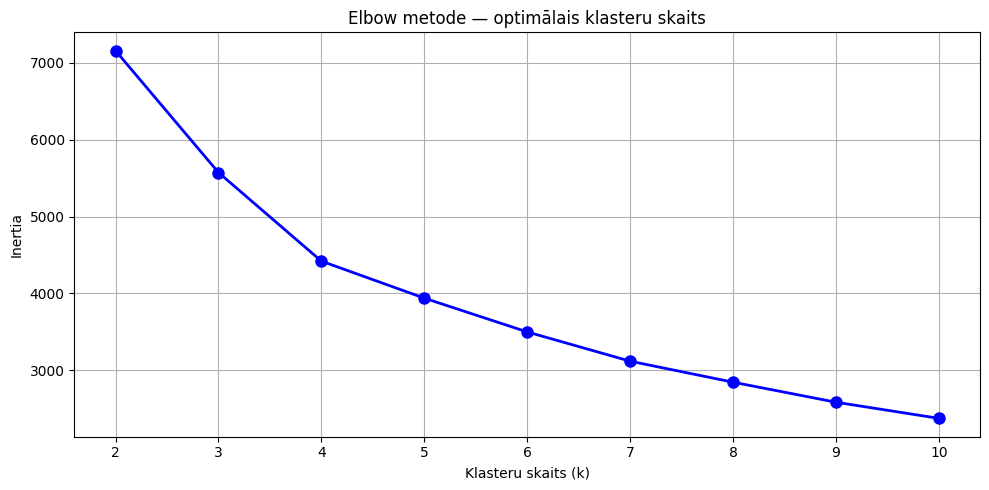

Inertias vērtības:
k=2: 7,157
k=3: 5,573
k=4: 4,420
k=5: 3,939
k=6: 3,500
k=7: 3,119
k=8: 2,846
k=9: 2,585
k=10: 2,376


In [99]:
# 2. uzdevums — Elbow metode
inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Klasteru skaits (k)')
plt.ylabel('Inertia')
plt.title('Elbow metode — optimālais klasteru skaits')
plt.xticks(k_range)
plt.grid(True)
plt.tight_layout()
plt.show()

print("Inertias vērtības:")
for k, inertia in zip(k_range, inertias):
    print(f"k={k}: {inertia:,.0f}")

In [100]:
# 2.2 Izvēlamies k=4
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"Klasteru sadalījums:")
print(df['cluster'].value_counts().sort_index())

Klasteru sadalījums:
cluster
0    1358
1     344
2     358
3     930
Name: count, dtype: int64


In [101]:
# 2.1 Apmāci abus modeļus
results = {}
for K in [3, 5]:
    km = KMeans(n_clusters=K, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    results[K] = {
        'labels': labels,
        'inertia': km.inertia_,
        'sizes': pd.Series(labels).value_counts().sort_index().tolist()
    }
    print(f"K={K}: inertia = {km.inertia_:.0f}, klasteru izmēri = {results[K]['sizes']}")

K=3: inertia = 5573, klasteru izmēri = [1516, 1108, 366]
K=5: inertia = 3939, klasteru izmēri = [900, 324, 882, 258, 626]


In [102]:
# 2.2 Pievieno klasterus
df['cluster_K3'] = results[3]['labels']
df['cluster_K5'] = results[5]['labels']

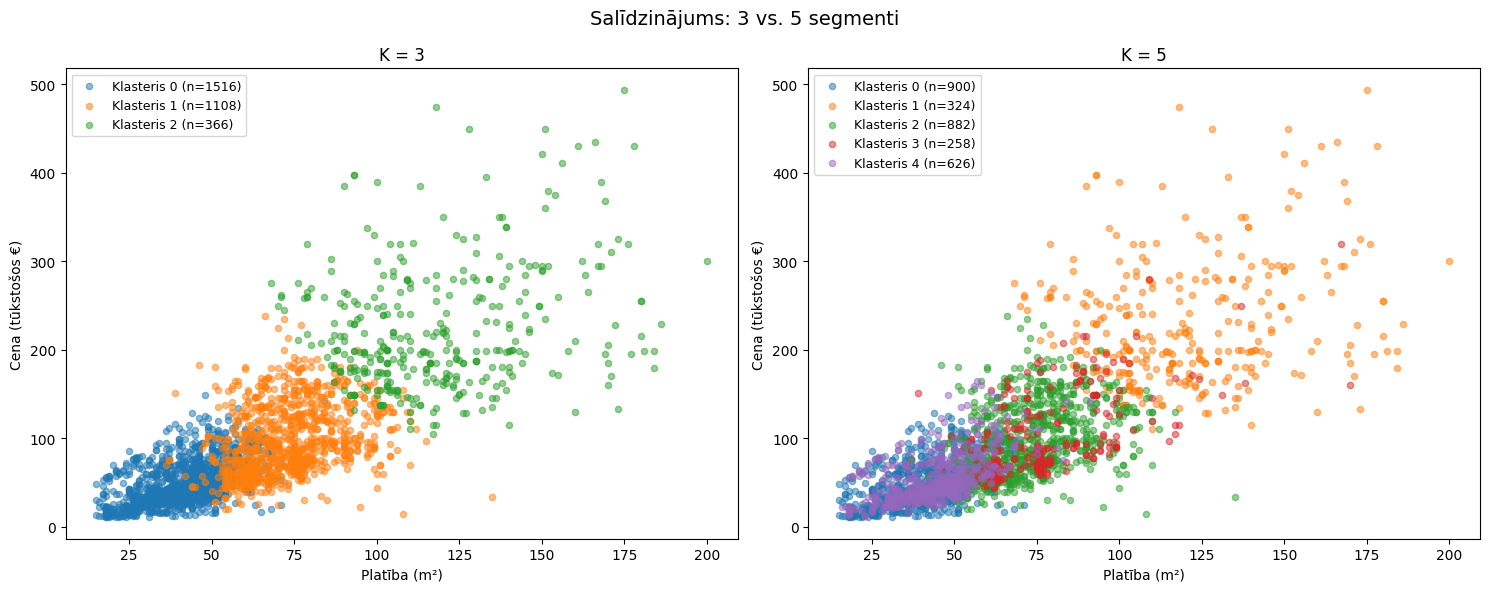

In [103]:
# 2.3 Vizualizācija
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, K in zip(axes, [3, 5]):
    for cluster_id in sorted(df[f'cluster_K{K}'].unique()):
        cluster_data = df[df[f'cluster_K{K}'] == cluster_id]
        ax.scatter(cluster_data['area'], cluster_data['price'] / 1000,
                   alpha=0.5, s=20, label=f'Klasteris {cluster_id} (n={len(cluster_data)})')
    ax.set_xlabel('Platība (m²)')
    ax.set_ylabel('Cena (tūkstošos €)')
    ax.set_title(f'K = {K}')
    ax.legend(loc='upper left', fontsize=9)
plt.suptitle('Salīdzinājums: 3 vs. 5 segmenti', fontsize=14)
plt.tight_layout()
plt.show()

### 2.4 Kuru izvēlēties — K=3 vai K=5?

**K=3 novērojums:**
Trīs skaidri atšķirīgi segmenti — lētie mazie
(zilie), vidējie (oranžie) un dārgie lielie (zaļie).
Segmenti ir viegli izskaidrojami biznesa valodā.

**K=5 novērojums:**
5 klasteri pārklājas vidusslānī — grūti izskaidrot
kāda biznesa vērtība ir papildu sadalījumam.

**Izvēle: K=3**
K=3 dod 3 skaidrus segmentus ko Latio tirgus
pētnieks var viegli nosaukt un aprakstīt klientiem.
K=5 sadala vidusslāni mākslīgi bez biznesa vērtības.

In [104]:
# 3. uzdevums — klasteru profili
df['cluster'] = results[3]['labels']

cluster_profiles = df.groupby('cluster')[cluster_features].mean()
print("Klasteru vidējie rādītāji:")
print(cluster_profiles.round(0))

print("\nKlasteru skaits:")
print(df['cluster'].value_counts().sort_index())

Klasteru vidējie rādītāji:
          price  area  rooms  floor
cluster                            
0        49,119    42      2      3
1        94,192    72      3      4
2       222,145   118      4      5

Klasteru skaits:
cluster
0    1516
1    1108
2     366
Name: count, dtype: int64


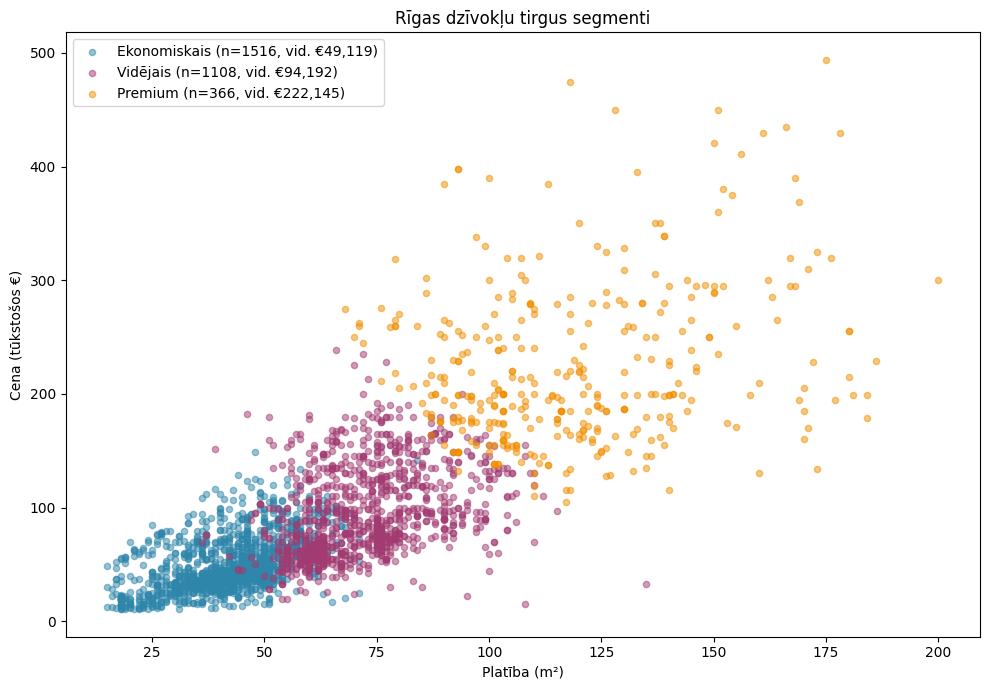

In [105]:
# 3.2 Vizualizācija ar segmentu nosaukumiem
segment_names = {
    0: 'Ekonomiskais',
    1: 'Vidējais',
    2: 'Premium'
}

colors = ['#2E86AB', '#A23B72', '#F18F01']

fig, ax = plt.subplots(figsize=(10, 7))
for cluster_id in sorted(df['cluster'].unique()):
    cluster_data = df[df['cluster'] == cluster_id]
    ax.scatter(cluster_data['area'], cluster_data['price'] / 1000,
               alpha=0.5, s=20, color=colors[cluster_id],
               label=f"{segment_names[cluster_id]} (n={len(cluster_data)}, vid. €{cluster_profiles.loc[cluster_id, 'price']:,.0f})")

ax.set_xlabel('Platība (m²)')
ax.set_ylabel('Cena (tūkstošos €)')
ax.set_title('Rīgas dzīvokļu tirgus segmenti')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [106]:
# 3.1 Izvēlies K=3
K = 3
df['cluster'] = df[f'cluster_K{K}']

In [107]:
# 3.2 Klasteru profili
profile = df.groupby('cluster').agg(
    count=('price', 'size'),
    median_price=('price', 'median'),
    median_area=('area', 'median'),
    median_rooms=('rooms', 'median'),
    median_floor=('floor', 'median'),
    median_price_per_m2=('price_per_meter', 'median'),
).round(0)

print("=== KLASTERU PROFILI ===")
print(profile)

=== KLASTERU PROFILI ===
         count  median_price  median_area  median_rooms  median_floor  \
cluster                                                                 
0         1516        44,000           43             2             3   
1         1108        85,000           70             3             3   
2          366       200,000          115             4             4   

         median_price_per_m2  
cluster                       
0                      1,024  
1                      1,140  
2                      1,818  


In [108]:
# 3.3 Top rajoni un mājas tipi
print("\n=== TOP 3 RAJONI KATRĀ KLASTERĪ ===")
for c in sorted(df['cluster'].unique()):
    top_districts = df[df['cluster'] == c]['district'].value_counts().head(3)
    print(f"\nKlasteris {c}:")
    print(top_districts.to_string())

print("\n=== TOP 3 MĀJAS TIPI KATRĀ KLASTERĪ ===")
for c in sorted(df['cluster'].unique()):
    top_series = df[df['cluster'] == c]['series'].value_counts().head(3)
    print(f"\nKlasteris {c}:")
    print(top_series.to_string())


=== TOP 3 RAJONI KATRĀ KLASTERĪ ===

Klasteris 0:
district
Centrs       340
Purvciems    159
Ķengarags    121

Klasteris 1:
district
Centrs       307
Purvciems    103
Pļavnieki     94

Klasteris 2:
district
Centrs        232
Citi           29
Āgenskalns     19

=== TOP 3 MĀJAS TIPI KATRĀ KLASTERĪ ===

Klasteris 0:
series
Pirmskara projekts     284
Lietuviešu projekts    188
Hruščova projekts      185

Klasteris 1:
series
Jaunais projekts      223
Pirmskara projekts    191
602. sērija           141

Klasteris 2:
series
Jaunais projekts      158
Pirmskara projekts    116
Renovēts               70


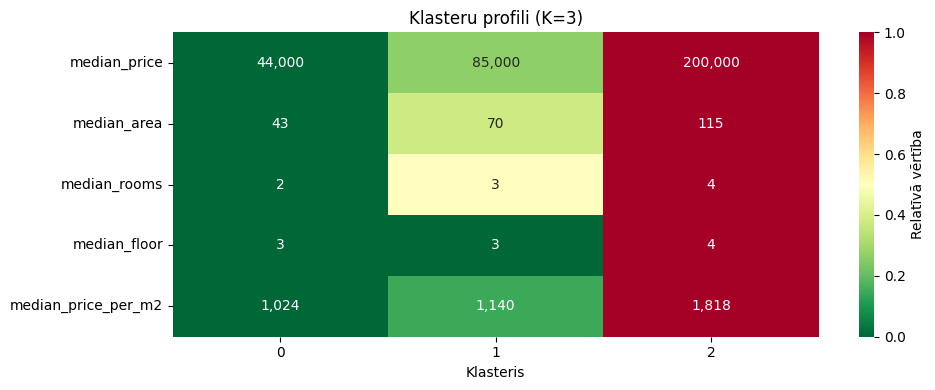

In [109]:
# 3.4 Heatmap
heatmap_data = profile[['median_price', 'median_area', 'median_rooms',
                         'median_floor', 'median_price_per_m2']].T

heatmap_norm = heatmap_data.sub(heatmap_data.min(axis=1), axis=0).div(
    heatmap_data.max(axis=1) - heatmap_data.min(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(heatmap_norm, annot=heatmap_data, fmt=',.0f', cmap='RdYlGn_r',
            cbar_kws={'label': 'Relatīvā vērtība'}, ax=ax)
ax.set_title(f'Klasteru profili (K={K})')
ax.set_xlabel('Klasteris')
plt.tight_layout()
plt.show()

### 3.5 Klasteru nosaukumi un profili

### Klasteris 0 — "Ekonomiski mazi dzīvokļi"
- **Tipisks dzīvoklis:** 2 ist., 43m², 3. stāvs
- **Cena:** €44,000 (~€1,024/m²)
- **Kur atrodas:** Centrs, Purvciems, Ķengarags
- **Mājas tips:** Pirmskara projekts, Lietuviešu, Hruščova
- **Tipiskais pircējs:** Pirmā mājokļa pircējs vai investors īrei
- **Latio rekomendācija:** Pozicionēt kā "sākuma līmeni" — labs īres tirgum

### Klasteris 1 — "Vidējie ģimenes mājokļi"
- **Tipisks dzīvoklis:** 3 ist., 70m², 3. stāvs
- **Cena:** €85,000 (~€1,140/m²)
- **Kur atrodas:** Centrs, Purvciems, Pļavnieki
- **Mājas tips:** Jaunais projekts, Pirmskara, 602. sērija
- **Tipiskais pircējs:** Ģimene ar bērniem, vidēji augsti ienākumi
- **Latio rekomendācija:** Lielākais segments — fokusēt mārketingu šeit

### Klasteris 2 — "Premium lielie dzīvokļi"
- **Tipisks dzīvoklis:** 4 ist., 115m², 4. stāvs
- **Cena:** €200,000 (~€1,818/m²)
- **Kur atrodas:** Centrs, Āgenskalns
- **Mājas tips:** Jaunais projekts, Pirmskara, Renovēts
- **Tipiskais pircējs:** Augsti ienākumi, ekspatrianti, investori
- **Latio rekomendācija:** Ekskluzīvs segments — personalizēts serviss!

In [110]:
# Palīgkods 4.1 atbildēm
print("=== JAUTĀJUMS 1 — IT speciālists, max €70,000 ===")
print(df[df['cluster'] == 0]['price'].describe().round(0))

print("\n=== JAUTĀJUMS 2 — Ģimene, 3 ist., max €100,000, nav hruščovka ===")
q2 = df[(df['cluster'] == 1) &
        (df['rooms'] >= 3) &
        (df['price'] <= 100000) &
        (df['series'] != 'Hruščova projekts')]
print(f"Sludinājumu skaits: {len(q2)}")

print("\n=== JAUTĀJUMS 3 — Investors, €250,000, Centrs ===")
q3 = df[(df['cluster'] == 2) &
        (df['district'] == 'Centrs') &
        (df['price'] <= 250000)]
print(f"Sludinājumu skaits: {len(q3)}")

=== JAUTĀJUMS 1 — IT speciālists, max €70,000 ===
count     1,516
mean     49,119
std      22,816
min      10,500
25%      33,500
50%      44,000
75%      61,925
max     149,000
Name: price, dtype: float64

=== JAUTĀJUMS 2 — Ģimene, 3 ist., max €100,000, nav hruščovka ===
Sludinājumu skaits: 656

=== JAUTĀJUMS 3 — Investors, €250,000, Centrs ===
Sludinājumu skaits: 156


### 4.1 Atbildes uz Latio klientu jautājumiem

**1. IT speciālists, max €70,000:**
Ieteiktu **Klasteri 0** (Ekonomiskais segments).
Mediānā cena €44,000 — ievērojami zem budžeta.
75% dzīvokļu šajā klasterī maksā zem €62,000 ✅

**2. Ģimene, 3 ist., max €100,000, nav hruščovka:**
Atbilst **Klasteris 1** (Vidējie ģimenes mājokļi).
Datos ir **656 sludinājumi** kas atbilst šiem kritērijiem ✅

**3. Investors, €250,000, Centrs, īrei tūristiem:**
Atbilst **Klasteris 2** (Premium).
Centrā zem €250,000 ir **156 sludinājumi** —
pietiekama izvēle (vairāk par 50)! ✅

In [111]:
# 4.2 Pārmaksas analīze
df['price_vs_cluster_median'] = df['price'] / df.groupby('cluster')['price'].transform('median')

overpriced = df[df['price_vs_cluster_median'] > 1.5].groupby('cluster').size()
total = df.groupby('cluster').size()
overpriced_pct = (overpriced / total * 100).round(1).fillna(0)

print("Sludinājumu īpatsvars, kas ir >1.5x klastera mediānas:")
print(overpriced_pct)

Sludinājumu īpatsvars, kas ir >1.5x klastera mediānas:
cluster
0   21
1   22
2   12
dtype: float64


### 4.2 Pārmaksas analīze

**Rezultāti:**
- Klasteris 0 (Ekonomiskais): 21% pārcenoti
- Klasteris 1 (Vidējais): 22% pārcenoti  
- Klasteris 2 (Premium): 12% pārcenoti

**Kurš klasteris satur visvairāk pārcenotu?**
Klasteris 1 (Vidējais) — 22% sludinājumu ir
vairāk nekā 1.5x virs klastera mediānas.

**Kāpēc?**
Klasteris 1 ir heterogēns — tajā ir gan padomju
sērijas dzīvokļi par €50,000, gan jaunie projekti
par €150,000+. Klasterizācija tos apvieno vienā
grupā, bet cenu diapazons ir ļoti plašs.
Premium klasteris (2) ir viendabīgāks — tur
visi dzīvokļi ir dārgi, tāpēc mazāk "izlecošu" cenu.

In [112]:
# 5.1 + 5.2 Sagatavo datus un vienreizējais split
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

features = ['rooms', 'area', 'floor', 'district', 'series']
X = pd.get_dummies(df[features], columns=['district', 'series'], drop_first=True)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
single_mae = mean_absolute_error(y_test, rf.predict(X_test))
print(f"Vienreizējs split MAE: €{single_mae:,.0f}")

Vienreizējs split MAE: €16,574


In [113]:
# 5.3 5-fold Cross-validation
rf_cv = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
scores = cross_val_score(rf_cv, X, y, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
mae_scores = -scores

print("5-fold CV MAE rezultāti pa fold'iem:")
for i, mae in enumerate(mae_scores, 1):
    print(f"  Fold {i}: €{mae:,.0f}")

print(f"\nVidējā: €{mae_scores.mean():,.0f}")
print(f"Std:    €{mae_scores.std():,.0f}")

5-fold CV MAE rezultāti pa fold'iem:
  Fold 1: €17,173
  Fold 2: €18,870
  Fold 3: €19,080
  Fold 4: €17,392
  Fold 5: €16,840

Vidējā: €17,871
Std:    €921


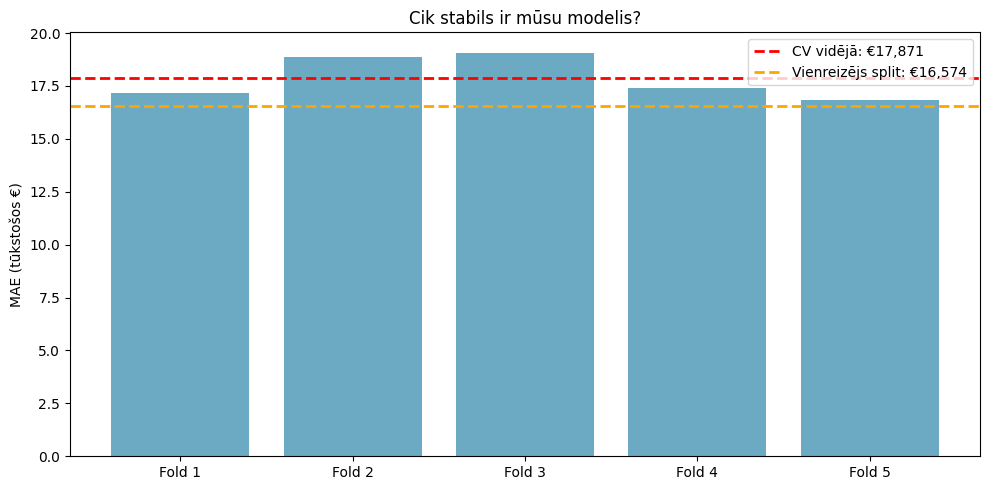

In [114]:
# 5.4 Vizualizācija
fig, ax = plt.subplots(figsize=(10, 5))
folds = [f'Fold {i}' for i in range(1, 6)]
ax.bar(folds, mae_scores / 1000, color='#2E86AB', alpha=0.7)
ax.axhline(mae_scores.mean() / 1000, color='red', linestyle='--', linewidth=2,
           label=f'CV vidējā: €{mae_scores.mean():,.0f}')
ax.axhline(single_mae / 1000, color='orange', linestyle='--', linewidth=2,
           label=f'Vienreizējs split: €{single_mae:,.0f}')
ax.set_ylabel('MAE (tūkstošos €)')
ax.set_title('Cik stabils ir mūsu modelis?')
ax.legend()
plt.tight_layout()
plt.show()

### 5.5 Biznesa interpretācija

**Vienreizējs split vs CV:**
Vienreizējs split deva MAE = €16,574 — tas bija
nedaudz "veiksmīgs" split, jo CV vidējā ir €17,871.
Starpība = €1,297 — modelis izskatījās labāks
nekā patiesībā!

**CV standarta novirze:**
Std = €921 — tas nozīmē modelis svārstās par
±€921 dažādos datos. Tas ir samērā stabils!

**Ko teiktu City24.lv direktoram:**
"Mūsu modelis NAV €16,574 MAE — tas bija viens
laimīgs sadalījums. Patiesā CV vidējā MAE ir
€17,871 — virs €15,000 mērķa. Modelis ir stabils
(std=€921), bet vēl nav gatavs ražošanai.
Vajadzīgi vairāk datu un papildu features!"

In [115]:
# 6.1 NEPAREIZAIS variants — data leakage
from sklearn.preprocessing import StandardScaler

scaler_bad = StandardScaler()
X_scaled_all = scaler_bad.fit_transform(X)

X_train_bad, X_test_bad, y_train_bad, y_test_bad = train_test_split(
    X_scaled_all, y, test_size=0.2, random_state=42
)

rf_bad = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_bad.fit(X_train_bad, y_train_bad)
mae_bad = mean_absolute_error(y_test_bad, rf_bad.predict(X_test_bad))
print(f"Ar data leakage MAE: €{mae_bad:,.0f} ← optimistiski izpušķots")

Ar data leakage MAE: €16,705 ← optimistiski izpušķots


In [116]:
# 6.2 PAREIZAIS variants — Pipeline
from sklearn.pipeline import make_pipeline

pipe = make_pipeline(
    StandardScaler(),
    RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
)

scores_clean = cross_val_score(pipe, X, y, cv=5,
                               scoring='neg_mean_absolute_error', n_jobs=-1)
mae_clean = -scores_clean
print(f"Ar Pipeline CV MAE: €{mae_clean.mean():,.0f} ± €{mae_clean.std():,.0f}")

Ar Pipeline CV MAE: €17,854 ± €902


In [117]:
# 6.3 Salīdzinājums
comparison = pd.DataFrame({
    'Metode': ['Ar data leakage', 'Pareizs Pipeline'],
    'MAE (€)': [f"€{mae_bad:,.0f}", f"€{mae_clean.mean():,.0f}"],
    'Uzticamība': ['BĪSTAMI — optimistiski izpušķots', 'DROŠS — patiess']
})
print(comparison.to_string(index=False))


          Metode MAE (€)                       Uzticamība
 Ar data leakage €16,705 BĪSTAMI — optimistiski izpušķots
Pareizs Pipeline €17,854                  DROŠS — patiess


### 6.4 Skaidrojums — Pipeline un data leakage

**Kāpēc mērogošana pirms split rada problēmu?**
Skalers fit() izmanto VISU datu vidējo un std —
ieskaitot testa datus. Tas nozīmē modelis
netieši "redz" testa datus pirms vajadzīgā brīža.
Rezultāts ir optimistisks MAE — €16,705 vs €17,854!

**Kāpēc šajā gadījumā leakage daudz neietekmē?**
RandomForest ir koku modelis — tas nav jutīgs
pret mērogu. Starpība ir tikai €1,149.
Bet LinearRegression vai KNN — tur leakage
būtu liela problēma, jo tie tieši izmanto
skaitļu lielumu aprēķinos!

**Kāpēc Pipeline ir labākais risinājums?**
1. Novērš data leakage automātiski
2. Kods ir tīrāks — viss vienā objektā
3. CV katram fold piemēro transformāciju
   atsevišķi — godīgi un reproducējami!

In [118]:
# 7.1 GridSearchCV
from sklearn.model_selection import GridSearchCV

pipe_grid = make_pipeline(
    StandardScaler(),
    RandomForestRegressor(random_state=42, n_jobs=-1)
)

param_grid = {
    'randomforestregressor__n_estimators': [100, 200, 400],
    'randomforestregressor__max_depth': [10, 15, 20]
}

grid = GridSearchCV(
    pipe_grid, param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid.fit(X, y)

print(f"\n=== REZULTĀTI ===")
print(f"Labākie parametri: {grid.best_params_}")
print(f"Labākā CV MAE: €{-grid.best_score_:,.0f}")

Fitting 3 folds for each of 9 candidates, totalling 27 fits

=== REZULTĀTI ===
Labākie parametri: {'randomforestregressor__max_depth': 20, 'randomforestregressor__n_estimators': 400}
Labākā CV MAE: €17,984


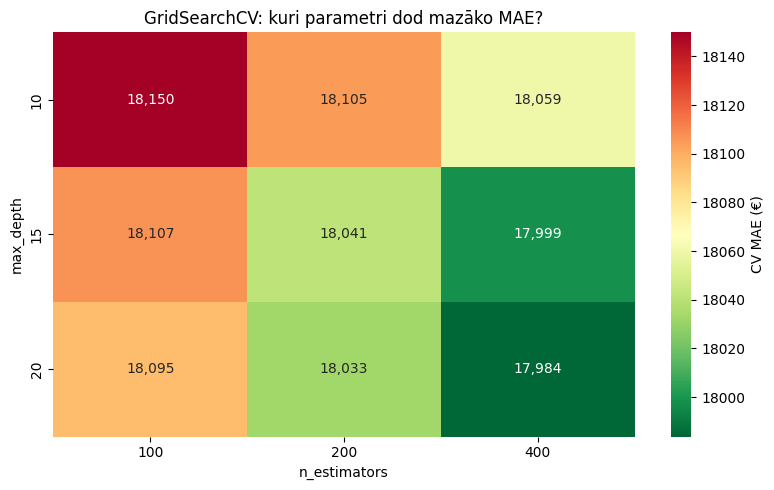

In [119]:
# 7.2 Heatmap rezultātiem
results_df = pd.DataFrame(grid.cv_results_)
pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_randomforestregressor__max_depth',
    columns='param_randomforestregressor__n_estimators'
)
pivot = -pivot

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='RdYlGn_r',
            cbar_kws={'label': 'CV MAE (€)'}, ax=ax)
ax.set_title('GridSearchCV: kuri parametri dod mazāko MAE?')
ax.set_xlabel('n_estimators')
ax.set_ylabel('max_depth')
plt.tight_layout()
plt.show()

### 7.3 GridSearchCV uzlabojuma novērtējums

**Uzlabojums pret sākotnējo konfigurāciju:**
Sākotnējais (n_estimators=200, max_depth=15): €18,041
Labākais (n_estimators=400, max_depth=20): €17,984
Uzlabojums: tikai €57!

**Vai uzlabojums ir nozīmīgs biznesa kontekstā?**
Nē — €57 starpība nav nozīmīga! City24.lv
direktoram nav svarīgi vai modelis kļūdās par
€17,984 vai €18,041. Abos gadījumos modelis
nav gatavs ražošanai (mērķis <€15,000).
Biznesa kontekstā nozīmīgs būtu uzlabojums
virs €1,000-2,000!

**Cik laika izmaksāja un kāpēc nedarītu ar 100 kombinācijām?**
Mūsu 9 kombinācijas × 3 folds = 27 modeļi.
100 kombinācijas × 5 folds = 500 modeļi —
tas varētu aizņemt stundas! Reālā produkcijā
izmanto RandomizedSearchCV — pārbauda tikai
nejaušu izlasi no visām kombinācijām!

In [120]:
# B.1 Instalē XGBoost
!pip install xgboost -q

In [121]:
# B.1 XGBoost vs Random Forest
from xgboost import XGBRegressor

pipe_xgb = make_pipeline(
    StandardScaler(),
    XGBRegressor(n_estimators=200, max_depth=6,
                 random_state=42, n_jobs=-1, verbosity=0)
)

scores_xgb = cross_val_score(pipe_xgb, X, y, cv=5,
                              scoring='neg_mean_absolute_error', n_jobs=-1)
mae_xgb = -scores_xgb

print(f"XGBoost CV MAE:      €{mae_xgb.mean():,.0f} ± €{mae_xgb.std():,.0f}")
print(f"Random Forest CV MAE: €{mae_scores.mean():,.0f} ± €{mae_scores.std():,.0f}")
print(f"\nUzlabojums: €{mae_scores.mean() - mae_xgb.mean():,.0f}")

XGBoost CV MAE:      €18,817 ± €862
Random Forest CV MAE: €17,871 ± €921

Uzlabojums: €-947


### B.1 XGBoost vs Random Forest

XGBoost CV MAE: €18,817 ± €862
Random Forest CV MAE: €17,871 ± €921

Random Forest uzvar par €947!

Kāpēc XGBoost zaudē?
XGBoost ir jutīgāks pret parametriem —
noklusējuma iestatījumi nav optimāli.
Ar GridSearchCV XGBoost varētu pārspēt RF.
Mācība: populārāks algoritms ne vienmēr
ir labāks bez pareizas parametru regulēšanas!

In [122]:
# B.2 Klasterizācija ar district un series
from sklearn.cluster import KMeans

# One-Hot encode kategoriskās kolonnas
X_cluster_full = pd.get_dummies(
    df[['price', 'area', 'rooms', 'floor', 'district', 'series']],
    columns=['district', 'series'],
    drop_first=True, dtype=int
)

# Normalizācija
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X_cluster_full)

# K-Means ar K=3
kmeans_full = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_full'] = kmeans_full.fit_predict(X_scaled_full)

# Salīdzinājums
print("=== KLASTERU PROFILI AR KATEGORISKĀM PAZĪMĒM ===")
print(df.groupby('cluster_full')[['price', 'area', 'rooms']].mean().round(0))

print("\n=== TOP 3 RAJONI KATRĀ KLASTERĪ ===")
for c in sorted(df['cluster_full'].unique()):
    print(f"\nKlasteris {c}:")
    print(df[df['cluster_full']==c]['district'].value_counts().head(3).to_string())

=== KLASTERU PROFILI AR KATEGORISKĀM PAZĪMĒM ===
               price  area  rooms
cluster_full                     
0             47,292    49      2
1            129,574    81      3
2            127,121    74      3

=== TOP 3 RAJONI KATRĀ KLASTERĪ ===

Klasteris 0:
district
Purvciems    186
Ķengarags    159
Pļavnieki    132

Klasteris 1:
district
Centrs           143
Purvciems         83
Ziepniekkalns     73

Klasteris 2:
district
Centrs        707
Vecrīga        32
Āgenskalns     27


In [123]:
print(f"Kolonnu skaits: {X_cluster_full.shape[1]}")
print(f"\nKolonnu nosaukumi:")
print(X_cluster_full.columns.tolist())
print(f"\nPirmās 3 rindas:")
print(X_cluster_full.head(3).to_string())

Kolonnu skaits: 40

Kolonnu nosaukumi:
['price', 'area', 'rooms', 'floor', 'district_Centrs', 'district_Citi', 'district_Daugavgrīva', 'district_Grīziņkalns', 'district_Imanta', 'district_Iļģuciems', 'district_Jugla', 'district_Krasta rajons', 'district_Maskavas priekšpilsēta', 'district_Mežaparks', 'district_Mežciems', 'district_Purvciems', 'district_Pļavnieki', 'district_Sarkandaugava', 'district_Teika', 'district_Vecmīlgrāvis', 'district_Vecrīga', 'district_Ziepniekkalns', 'district_Zolitūde', 'district_Āgenskalns', 'district_Ķengarags', 'district_Šampēteris-Pleskodāle', 'series_104. sērija', 'series_119. sērija', 'series_467. sērija', 'series_602. sērija', 'series_Hruščova projekts', 'series_Jaunais projekts', 'series_Lietuviešu projekts', 'series_Mazģimeņu projekts', 'series_Pirmskara projekts', 'series_Privātmāja', 'series_Renovēts', 'series_Specprojekts', 'series_Staļina projekts', 'series_Čehu projekts']

Pirmās 3 rindas:
    price  area  rooms  floor  district_Centrs  district